mypy: disable-error-code="import-untyped,no-redef,misc"

# 2026-03 - Replicating the Param-Eq Paper in Egglog

This notebook rebuilds the de Franca and Kronberger (2023) paper figures from
the archived Haskell experiment outputs and compares them to an Egglog
translation of the older hegg-era simplification pipeline.

It is artifacts-first:
- it reads normalized Haskell artifacts from `python/exp/param_eq_paper/artifacts`
- it reads the Egglog corpus results from the same directory
- it does not extract tarballs or run Haskell at notebook execution time

Offline regeneration commands from the repository root:
- `uv run --project . python python/exp/param_eq_paper/normalize_archives.py`
- `uv run --project . python python/exp/param_eq_paper/run_egglog_corpus.py`
- `uv run --project . python docs/explanation/2026_03_param_eq_paper_replication.py`

The executed `.ipynb` shown in GitHub is generated from this `py:light` file.

In [1]:
from __future__ import annotations

from io import StringIO
from pathlib import Path
from typing import Any

import altair as alt
import pandas as pd

SVGDisplay: Any | None

try:
    from IPython.display import Markdown, SVG as _SVG, display

    SVGDisplay = _SVG
except ImportError:  # pragma: no cover

    def Markdown(text: str) -> str:  # type: ignore[misc]
        return text

    SVGDisplay = None

    def display(obj: object) -> None:  # pragma: no cover
        print(obj)


alt.data_transformers.disable_max_rows()
alt.renderers.enable("default")

ALGORITHM_ORDER = ["Bingo", "EPLEX", "GP-GOMEA", "Operon", "PySR", "SBP"]
MODE_LABELS = {
    "egglog-baseline": "Egglog baseline",
}


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "python" / "egglog").exists():
            return candidate
    msg = f"Could not locate egg-smol-python repo root from {start}"
    raise FileNotFoundError(msg)


REPO_ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve())
ARTIFACT_DIR = REPO_ROOT / "python" / "exp" / "param_eq_paper" / "artifacts"
HASKELL_PATH = ARTIFACT_DIR / "haskell_paper_rows.csv"
EGGLOG_PATH = ARTIFACT_DIR / "egglog_paper_rows.csv"
RUNTIME_PATH = ARTIFACT_DIR / "pagie_runtime_scatter.csv"
MANIFEST_PATH = ARTIFACT_DIR / "artifact_manifest.json"

for required_path in [HASKELL_PATH, EGGLOG_PATH, RUNTIME_PATH]:
    if not required_path.exists():
        msg = f"Missing required artifact: {required_path}"
        raise FileNotFoundError(msg)


def _coerce_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def _paper_haskell_frame() -> pd.DataFrame:
    frame = pd.read_csv(HASKELL_PATH)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "n_params",
            "n_rank",
        ],
    )


def _paper_egglog_frame() -> pd.DataFrame:
    frame = pd.read_csv(EGGLOG_PATH)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "n_params",
            "n_rank",
            "orig_runtime_ms",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_total_size",
            "orig_egraph_nodes",
            "orig_eclass_count",
            "orig_passes",
            "orig_extracted_cost",
            "sympy_runtime_ms",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "sympy_total_size",
            "sympy_egraph_nodes",
            "sympy_eclass_count",
            "sympy_passes",
            "sympy_extracted_cost",
        ],
    )


def _paper_runtime_frame() -> pd.DataFrame:
    frame = pd.read_csv(RUNTIME_PATH)
    return _coerce_numeric(frame, ["node_count", "runtime_ms"])


def add_paper_metrics(frame: pd.DataFrame, *, prefix: str) -> pd.DataFrame:
    result = frame.copy()
    result["orig_x_egg"] = (result[prefix + "orig_params"] - result[prefix + "simpl_params"]) / result[
        prefix + "orig_params"
    ]
    result["orig_x_sympy"] = (result[prefix + "orig_params"] - result[prefix + "orig_params_sympy"]) / result[
        prefix + "orig_params"
    ]
    result["orig_x_sympyegg"] = (result[prefix + "orig_params"] - result[prefix + "simpl_params_sympy"]) / result[
        prefix + "orig_params"
    ]
    result["sympy_x_egg"] = (result[prefix + "orig_params_sympy"] - result[prefix + "simpl_params"]) / result[
        prefix + "orig_params_sympy"
    ]
    result["sympyegg_x_egg"] = (result[prefix + "simpl_params_sympy"] - result[prefix + "simpl_params"]) / result[
        prefix + "simpl_params_sympy"
    ]
    result["orig_rank"] = result["n_params"] - result["n_rank"]
    result["simpl_rank"] = result[prefix + "simpl_params"] - result["n_rank"]
    result["sympy_rank"] = result[prefix + "orig_params_sympy"] - result["n_rank"]
    return result


def melt_methods(frame: pd.DataFrame, *, columns: dict[str, str], value_name: str) -> pd.DataFrame:
    melted = frame.melt(
        id_vars=["dataset", "algorithm", "raw_index"],
        value_vars=list(columns.values()),
        var_name="method_key",
        value_name=value_name,
    )
    inverse = {value: key for key, value in columns.items()}
    melted["method"] = melted["method_key"].map(inverse)
    return melted.drop(columns=["method_key"])


def boxplot_chart(frame: pd.DataFrame, *, y: str, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_boxplot(size=24)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y(f"{y}:Q", title=y.replace("_", " ")),
            column=alt.Column("method:N", title=None),
        )
        .properties(title=title, width=120, height=280)
        .resolve_scale(y="shared")
    )


def rank_boxplot(frame: pd.DataFrame, *, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_boxplot(size=26)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y("simpl_rank:Q", title="simplified params - rank"),
            column=alt.Column("dataset:N", title=None),
        )
        .properties(title=title, width=180, height=280)
        .resolve_scale(y="shared")
    )


def comparison_table(frame: pd.DataFrame, *, implementation: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for dataset in ["pagie", "kotanchek"]:
        dataset_frame = frame[frame["dataset"] == dataset]
        for algorithm in ALGORITHM_ORDER:
            algo_frame = dataset_frame[dataset_frame["algorithm"] == algorithm]
            for delta in [0, 1]:
                eligible = algo_frame[algo_frame["orig_rank"] > delta]
                percent = float("nan")
                if not eligible.empty:
                    percent = 100.0 * (eligible["simpl_rank"] <= delta).sum() / len(eligible)
                rows.append({
                    "implementation": implementation,
                    "dataset": dataset,
                    "algorithm": algorithm,
                    "delta": f"Δ {'==' if delta == 0 else '<='} {delta}",
                    "percent": percent,
                })
    return pd.DataFrame(rows)


def table4_wide(frame: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    zero = frame[frame["delta"] == "Δ == 0"][[*index_columns, "percent"]].rename(columns={"percent": "Δ == 0"})
    one = frame[frame["delta"] == "Δ <= 1"][[*index_columns, "percent"]].rename(columns={"percent": "Δ <= 1"})
    return zero.merge(one, on=index_columns, how="outer")


def runtime_scatter(frame: pd.DataFrame, *, x: str, y: str, color: str, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_circle(size=48, opacity=0.7)
        .encode(
            x=alt.X(f"{x}:Q"),
            y=alt.Y(f"{y}:Q"),
            color=alt.Color(f"{color}:N"),
            tooltip=list(frame.columns),
        )
        .properties(title=title, width=360, height=300)
    )


def status_summary_chart(frame: pd.DataFrame, *, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_bar()
        .encode(
            x=alt.X("count:Q", title="rows"),
            y=alt.Y("status:N", sort="-x", title=None),
            color=alt.Color("status:N", legend=None),
            column=alt.Column("mode:N", title=None),
        )
        .properties(title=title, width=180, height=180)
    )


def show_chart(chart: alt.Chart) -> None:
    if SVGDisplay is None:  # pragma: no cover
        print(chart)
        return
    buffer = StringIO()
    chart.save(buffer, format="svg")
    display(SVGDisplay(buffer.getvalue()))


haskell = add_paper_metrics(_paper_haskell_frame(), prefix="")
egglog = add_paper_metrics(_paper_egglog_frame(), prefix="")
runtime_rows = _paper_runtime_frame()

egglog_baseline = egglog[egglog["mode"] == "egglog-baseline"].copy()
haskell_box_methods = {
    "EqSat": "orig_x_egg",
    "Sympy": "orig_x_sympy",
    "Sympy + EqSat": "orig_x_sympyegg",
}
comparison_methods = {
    "Sympy x EqSat": "sympy_x_egg",
    "Sympy + EqSat x EqSat": "sympyegg_x_egg",
}

haskell_table4 = comparison_table(haskell, implementation="Haskell")
egglog_table4 = pd.concat(
    [
        comparison_table(egglog_baseline, implementation="Egglog baseline"),
    ],
    ignore_index=True,
)

baseline_compare = egglog_baseline.merge(
    haskell[
        [
            "dataset",
            "raw_index",
            "algorithm",
            "simpl_params",
            "simpl_params_sympy",
            "orig_params",
            "orig_params_sympy",
        ]
    ],
    on=["dataset", "raw_index", "algorithm"],
    suffixes=("_egglog", "_haskell"),
)
baseline_compare["orig_param_match"] = (
    baseline_compare["simpl_params_egglog"] == baseline_compare["simpl_params_haskell"]
)
baseline_compare["sympy_param_match"] = (
    baseline_compare["simpl_params_sympy_egglog"] == baseline_compare["simpl_params_sympy_haskell"]
)

baseline_compare["orig_abs_gap"] = (
    baseline_compare["simpl_params_egglog"] - baseline_compare["simpl_params_haskell"]
).abs()
status_rows = egglog_baseline.assign(status=egglog_baseline["orig_status"], mode_label="Egglog baseline")[
    ["status", "mode_label"]
].rename(columns={"mode_label": "mode"})

## 1. Provenance

This notebook uses two archives supplied by the original author:
- `param-eq-haskell`, which contains the archived experiment tables and the
  original plotting notebook used to build the paper figures
- `pandoc-symreg`, which contains the older hegg-style equality engine that
  informed the later follow-up experiments

The normalized artifacts already include the paper cleanup from the original
notebook:
- drop `FEAT`
- rename `SRjl -> PySR`
- rename `GOMEA -> GP-GOMEA`
- drop rows `16, 162` for Pagie
- drop row `1` for Kotanchek
- drop rows with missing rank data

In [2]:
summary = [
    f"- Paper rows available after cleanup: `{len(haskell)}`",
    f"- Pagie rows after cleanup: `{int((haskell['dataset'] == 'pagie').sum())}`",
    f"- Kotanchek rows after cleanup: `{int((haskell['dataset'] == 'kotanchek').sum())}`",
    f"- Pagie runtime scatter rows: `{len(runtime_rows)}`",
]
display(Markdown("## Artifact Overview\n\n" + "\n".join(summary)))

## Artifact Overview

- Paper rows available after cleanup: `341`
- Pagie rows after cleanup: `174`
- Kotanchek rows after cleanup: `167`
- Pagie runtime scatter rows: `213`

## 2. Recreating the Haskell Paper Figures

The next figures use exactly the same formulas as the archived Haskell
plotting notebook.

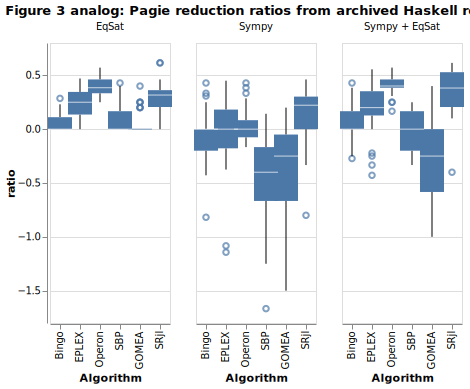

In [3]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        y="ratio",
        title="Figure 3 analog: Pagie reduction ratios from archived Haskell results",
    )
)

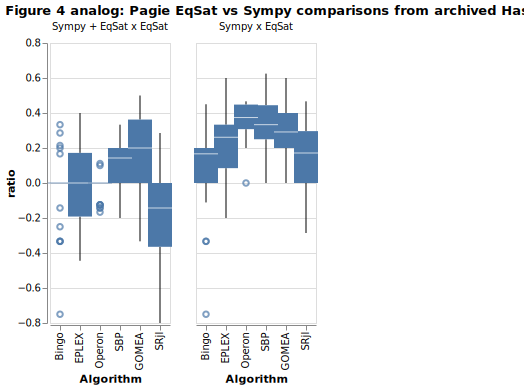

In [4]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        y="ratio",
        title="Figure 4 analog: Pagie EqSat vs Sympy comparisons from archived Haskell results",
    )
)

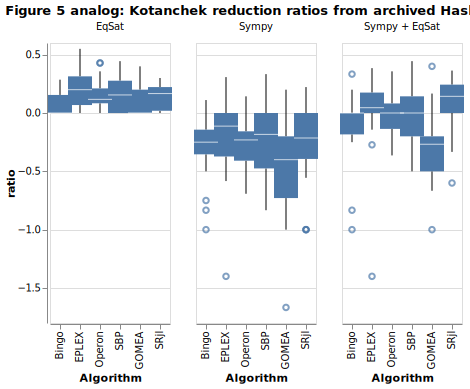

In [5]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        y="ratio",
        title="Figure 5 analog: Kotanchek reduction ratios from archived Haskell results",
    )
)

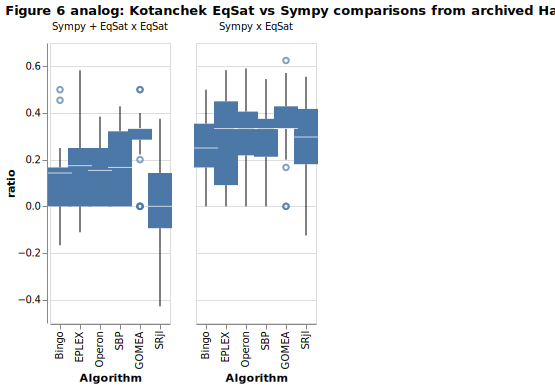

In [6]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        y="ratio",
        title="Figure 6 analog: Kotanchek EqSat vs Sympy comparisons from archived Haskell results",
    )
)

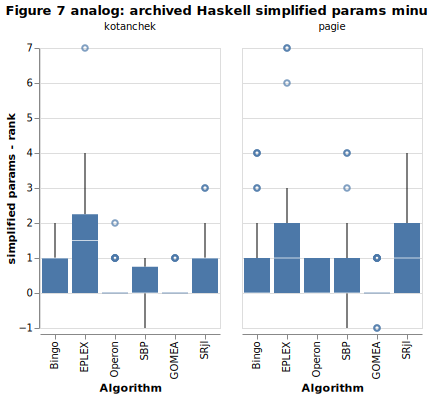

In [7]:
show_chart(rank_boxplot(haskell, title="Figure 7 analog: archived Haskell simplified params minus rank"))

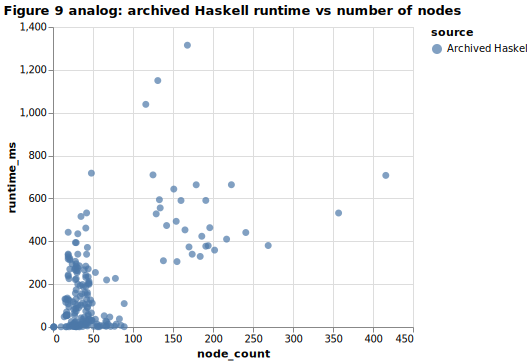

In [8]:
show_chart(
    runtime_scatter(
        runtime_rows.assign(source="Archived Haskell"),
        x="node_count",
        y="runtime_ms",
        color="source",
        title="Figure 9 analog: archived Haskell runtime vs number of nodes",
    )
)

In [9]:
display(Markdown("### Table 4 analog from archived Haskell results"))
display(table4_wide(haskell_table4, ["dataset", "algorithm"]).round(2))

### Table 4 analog from archived Haskell results

,dataset,algorithm,Δ == 0,Δ <= 1
0,kotanchek,Bingo,22.22,66.67
1,kotanchek,EPLEX,18.75,37.50
2,kotanchek,GP-GOMEA,NaN,NaN
3,kotanchek,Operon,74.07,94.44
4,kotanchek,PySR,NaN,NaN
5,kotanchek,SBP,65.22,100.00
6,pagie,Bingo,27.78,33.33
7,pagie,EPLEX,28.00,45.45
8,pagie,GP-GOMEA,NaN,NaN
9,pagie,Operon,66.67,100.00


In [10]:
display(
    Markdown(
        "### Figure 8 status\n\n"
        "The provided archives do not include the bulk Feynman/Operon result table "
        "needed to reproduce Figure 8 exactly, so this notebook marks that figure "
        "as unavailable rather than fabricating an approximation."
    )
)

### Figure 8 status

The provided archives do not include the bulk Feynman/Operon result table needed to reproduce Figure 8 exactly, so this notebook marks that figure as unavailable rather than fabricating an approximation.

## 3. Egglog Translation of the Older Hegg-Era Pipeline

The Egglog runner uses the archived experiment harness as the baseline:
- the older expression language from the paper-era code
- the paper-era extraction cost model
- the `FixTree.hs` rewrite loop and backoff scheduler

In [11]:
baseline_summary = [
    f"- Egglog baseline original-input status counts: `{egglog_baseline['orig_status'].value_counts().to_dict()}`",
    f"- Egglog baseline sympy-input status counts: `{egglog_baseline['sympy_status'].value_counts().to_dict()}`",
]
display(Markdown("## Egglog Run Overview\n\n" + "\n".join(baseline_summary)))

## Egglog Run Overview

- Egglog baseline original-input status counts: `{'saturated': 310, 'timeout': 31}`
- Egglog baseline sympy-input status counts: `{'saturated': 340, 'timeout': 1}`

## 4. Haskell vs Egglog Comparison

The next figures mirror the paper plots with Egglog data. For the Egglog
charts, "Sympy" means the archived Sympy output re-counted by the Egglog
parser, and "Sympy + EqSat" means running the Egglog EqSat translation on the
archived Sympy expression.

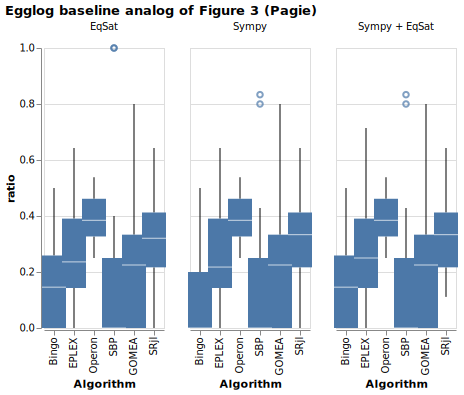

In [12]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 3 (Pagie)",
    )
)

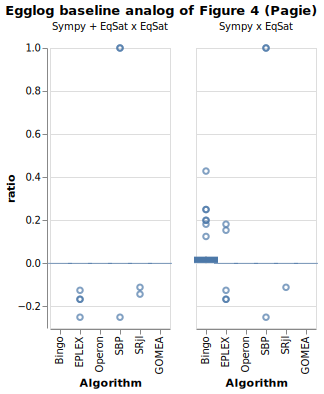

In [13]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 4 (Pagie)",
    )
)

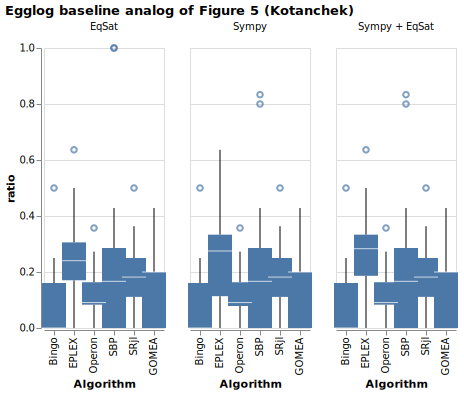

In [14]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 5 (Kotanchek)",
    )
)

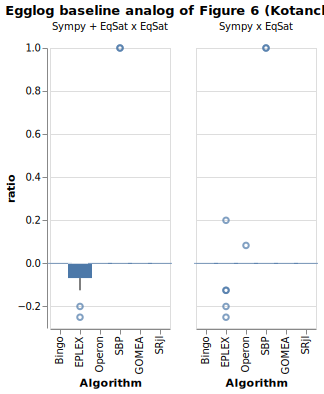

In [15]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 6 (Kotanchek)",
    )
)

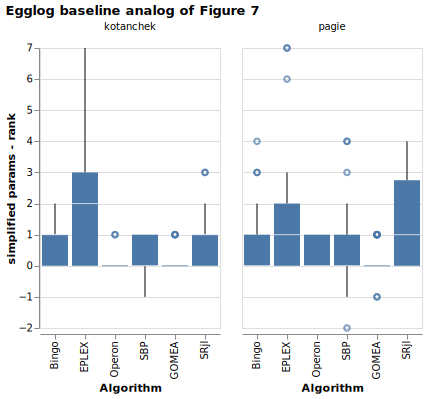

In [16]:
show_chart(rank_boxplot(egglog_baseline, title="Egglog baseline analog of Figure 7"))

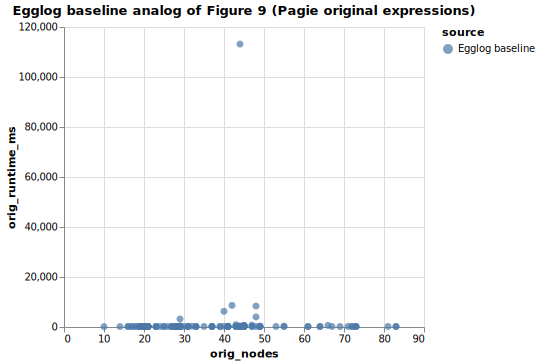

In [17]:
show_chart(
    runtime_scatter(
        egglog_baseline[egglog_baseline["dataset"] == "pagie"].assign(source="Egglog baseline"),
        x="orig_nodes",
        y="orig_runtime_ms",
        color="source",
        title="Egglog baseline analog of Figure 9 (Pagie original expressions)",
    )
)

In [18]:
display(Markdown("### Table 4 analogs for Egglog"))
display(table4_wide(egglog_table4, ["implementation", "dataset", "algorithm"]).round(2))

### Table 4 analogs for Egglog

,implementation,dataset,algorithm,Δ == 0,Δ <= 1
0,Egglog baseline,kotanchek,Bingo,22.22,66.67
1,Egglog baseline,kotanchek,EPLEX,12.50,25.00
2,Egglog baseline,kotanchek,GP-GOMEA,NaN,NaN
3,Egglog baseline,kotanchek,Operon,62.96,61.11
4,Egglog baseline,kotanchek,PySR,NaN,NaN
5,Egglog baseline,kotanchek,SBP,60.87,90.91
6,Egglog baseline,pagie,Bingo,50.00,66.67
7,Egglog baseline,pagie,EPLEX,32.00,40.91
8,Egglog baseline,pagie,GP-GOMEA,NaN,NaN
9,Egglog baseline,pagie,Operon,50.00,80.00


In [19]:
exact_match_rows = pd.DataFrame([
    {
        "mode": "Egglog baseline",
        "input": "original expressions",
        "exact_param_matches": int(baseline_compare["orig_param_match"].sum()),
        "total_rows": len(baseline_compare),
    },
    {
        "mode": "Egglog baseline",
        "input": "sympy expressions",
        "exact_param_matches": int(baseline_compare["sympy_param_match"].sum()),
        "total_rows": len(baseline_compare),
    },
])
display(Markdown("### Exact-match counts against archived Haskell parameter totals"))
display(exact_match_rows)

### Exact-match counts against archived Haskell parameter totals

,mode,input,exact_param_matches,total_rows
0,Egglog baseline,original expressions,286,341
1,Egglog baseline,sympy expressions,125,341


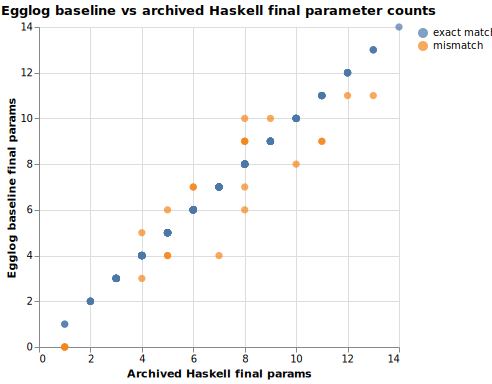

In [20]:
baseline_orig_scatter = baseline_compare[baseline_compare["orig_status"] == "saturated"].copy()
baseline_orig_scatter["match"] = baseline_orig_scatter["orig_param_match"].map({True: "exact match", False: "mismatch"})
show_chart(
    alt.Chart(baseline_orig_scatter)
    .mark_circle(size=52, opacity=0.7)
    .encode(
        x=alt.X("simpl_params_haskell:Q", title="Archived Haskell final params"),
        y=alt.Y("simpl_params_egglog:Q", title="Egglog baseline final params"),
        color=alt.Color("match:N", title=None),
        tooltip=["dataset", "algorithm", "algo_row", "simpl_params_haskell", "simpl_params_egglog", "orig_rendered"],
    )
    .properties(title="Egglog baseline vs archived Haskell final parameter counts", width=360, height=320)
)

In [21]:
baseline_summary_frame = pd.DataFrame([
    {
        "mode": "Egglog baseline",
        "orig_non_saturated_rows": int((egglog_baseline["orig_status"] != "saturated").sum()),
        "sympy_non_saturated_rows": int((egglog_baseline["sympy_status"] != "saturated").sum()),
        "median_orig_runtime_ms": float(egglog_baseline["orig_runtime_ms"].median()),
        "median_sympy_runtime_ms": float(egglog_baseline["sympy_runtime_ms"].median()),
    },
])
display(Markdown("### Egglog baseline summary"))
display(baseline_summary_frame.round(2))

### Egglog baseline summary

,mode,orig_non_saturated_rows,sympy_non_saturated_rows,median_orig_runtime_ms,median_sympy_runtime_ms
0,Egglog baseline,31,1,196.97,177.62


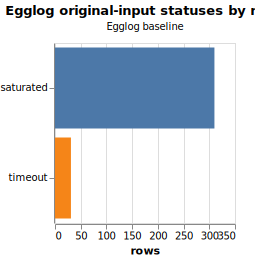

In [22]:
show_chart(
    status_summary_chart(
        status_rows.groupby(["mode", "status"]).size().reset_index(name="count"),
        title="Egglog original-input statuses by mode",
    )
)

In [23]:
display(
    Markdown(
        "\n".join([
            "## Comparison Summary",
            "",
            f"- Egglog baseline exactly matches archived Haskell final parameter counts on `{int(baseline_compare['orig_param_match'].sum())}` of `{len(baseline_compare)}` original-expression rows.",
            f"- Egglog baseline exactly matches archived Haskell `Sympy + EqSat` parameter counts on `{int(baseline_compare['sympy_param_match'].sum())}` of `{len(baseline_compare)}` sympy-expression rows.",
            f"- Egglog baseline original-input timeouts or failures occur on `{int((egglog_baseline['orig_status'] != 'saturated').sum())}` of `{len(egglog_baseline)}` paper rows.",
            f"- Egglog baseline sympy-input timeouts or failures occur on `{int((egglog_baseline['sympy_status'] != 'saturated').sum())}` of `{len(egglog_baseline)}` paper rows.",
        ])
    )
)

## Comparison Summary

- Egglog baseline exactly matches archived Haskell final parameter counts on `286` of `341` original-expression rows.
- Egglog baseline exactly matches archived Haskell `Sympy + EqSat` parameter counts on `125` of `341` sympy-expression rows.
- Egglog baseline original-input timeouts or failures occur on `31` of `341` paper rows.
- Egglog baseline sympy-input timeouts or failures occur on `1` of `341` paper rows.

## 5. Current Limitations and Likely A/C Effects

The statements below are derived from the loaded artifacts and then connected
back to the rewrite structure in the archived source.

In [24]:
baseline_failures = egglog_baseline[egglog_baseline["orig_status"] != "saturated"].copy()
failure_by_algorithm = baseline_failures.groupby("algorithm").size().sort_values(ascending=False)
sympy_success_delta = int(
    (egglog_baseline["sympy_status"] == "saturated").sum() - (egglog_baseline["orig_status"] == "saturated").sum()
)
source_node_sizes = haskell[["dataset", "raw_index", "algorithm", "orig_nodes"]].rename(
    columns={"orig_nodes": "source_orig_nodes"}
)
baseline_failures_with_sizes = baseline_failures.merge(
    source_node_sizes, on=["dataset", "raw_index", "algorithm"], how="left"
)
baseline_sat_with_sizes = egglog_baseline[egglog_baseline["orig_status"] == "saturated"].merge(
    source_node_sizes,
    on=["dataset", "raw_index", "algorithm"],
    how="left",
)
baseline_timeout_median_nodes = baseline_failures_with_sizes["source_orig_nodes"].median()
baseline_sat_median_nodes = baseline_sat_with_sizes["source_orig_nodes"].median()

conclusion_lines = [
    f"- The Egglog baseline saturates on `{int((egglog_baseline['orig_status'] == 'saturated').sum())}` of `{len(egglog_baseline)}` original paper rows, but on `{int((egglog_baseline['sympy_status'] == 'saturated').sum())}` of `{len(egglog_baseline)}` archived Sympy rows.",
    f"- The archived Sympy inputs therefore remove `{sympy_success_delta}` baseline failures, which is consistent with the paper's observation that preprocessing can cut down the parameter-reduction problem before EqSat runs.",
    f"- Using the archived source-node counts for the same rows, the median original node count for Egglog baseline failures is `{baseline_timeout_median_nodes:.1f}`, versus `{baseline_sat_median_nodes:.1f}` for saturated rows; the runtime tail still tracks expression size.",
    f"- Failures are concentrated in `{', '.join(f'{alg} ({count})' for alg, count in failure_by_algorithm.items()) or 'none'}`, which points to specific expression families rather than a uniform issue across all algorithms.",
    f"- The baseline still has a median original-input gap-to-rank of `{float(egglog_baseline['simpl_rank'].median()):.2f}`, versus `{float(haskell['simpl_rank'].median()):.2f}` in the archived Haskell results.",
    "",
    "The archived rule sets suggest that A/C pressure is most likely to affect:",
    "- `+` and `*` associativity and commutativity rewrites, especially when chained through factorization-style rewrites and reciprocal rewrites.",
    "- distributivity and refactorization rules that depend on binary tree shape, such as `(x*y) + (x*z) -> x*(y+z)` and its surrounding normalization rules.",
    "- power-merging and logarithm rewrites, where repeated multiplication and reassociation can create many equivalent binary trees before extraction.",
    "",
    "The best follow-up points for a multiset experiment are:",
    "- additive islands that currently rely on repeated binary reassociation before a factorization rewrite becomes visible",
    "- multiplicative islands that feed reciprocal and logarithm rewrites",
    "- classes where constant-analysis guards still block paper rewrites that the Haskell implementation can fire after rebuild",
    "",
    "The expected outcomes to test next are:",
    "- a shorter runtime tail on the Pagie expressions that currently timeout in Egglog baseline",
    "- fewer rows where Egglog remains above the archived rank target after simplification",
    "- less dependence on repeated binary reassociation once A/C-heavy structure is containerized directly",
]
display(Markdown("## Conclusion\n\n" + "\n".join(conclusion_lines)))

## Conclusion

- The Egglog baseline saturates on `310` of `341` original paper rows, but on `340` of `341` archived Sympy rows.
- The archived Sympy inputs therefore remove `30` baseline failures, which is consistent with the paper's observation that preprocessing can cut down the parameter-reduction problem before EqSat runs.
- Using the archived source-node counts for the same rows, the median original node count for Egglog baseline failures is `45.0`, versus `30.0` for saturated rows; the runtime tail still tracks expression size.
- Failures are concentrated in `Operon (14), SRjl (9), EPLEX (4), Bingo (2), GOMEA (1), SBP (1)`, which points to specific expression families rather than a uniform issue across all algorithms.
- The baseline still has a median original-input gap-to-rank of `0.00`, versus `0.00` in the archived Haskell results.

The archived rule sets suggest that A/C pressure is most likely to affect:
- `+` and `*` associativity and commutativity rewrites, especially when chained through factorization-style rewrites and reciprocal rewrites.
- distributivity and refactorization rules that depend on binary tree shape, such as `(x*y) + (x*z) -> x*(y+z)` and its surrounding normalization rules.
- power-merging and logarithm rewrites, where repeated multiplication and reassociation can create many equivalent binary trees before extraction.

The best follow-up points for a multiset experiment are:
- additive islands that currently rely on repeated binary reassociation before a factorization rewrite becomes visible
- multiplicative islands that feed reciprocal and logarithm rewrites
- classes where constant-analysis guards still block paper rewrites that the Haskell implementation can fire after rebuild

The expected outcomes to test next are:
- a shorter runtime tail on the Pagie expressions that currently timeout in Egglog baseline
- fewer rows where Egglog remains above the archived rank target after simplification
- less dependence on repeated binary reassociation once A/C-heavy structure is containerized directly